In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [23]:
data = pd.read_csv('datasets/Credit_Card_Transactions.csv')

In [24]:
data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2.703186e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495.0,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0,28705.0
1,1,2019-01-01 00:00:44,6.304233e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149.0,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0,NaN
2,2,2019-01-01 00:00:51,3.885949e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154.0,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0,83236.0
3,3,2019-01-01 00:01:16,3.534094e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939.0,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0,NaN
4,4,2019-01-01 00:03:06,3.755342e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99.0,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0,22844.0


In [25]:
# data.isna().sum()
# data[data['cc_num'].isna()]
data.dropna(subset=['cc_num'], inplace=True)
# data.isna().sum()

In [26]:
data['trans_hour'] = pd.to_datetime(data['trans_date_trans_time']).dt.hour

In [29]:
features = data[['amt', 'trans_hour']]
features.describe()

,amt,trans_hour
count,154098.000000,154098.000000
mean,71.677549,12.804021
std,159.441101,6.821447
min,1.000000,0.000000
25%,9.650000,7.000000
50%,47.750000,14.000000
75%,83.730000,19.000000
max,15034.180000,23.000000


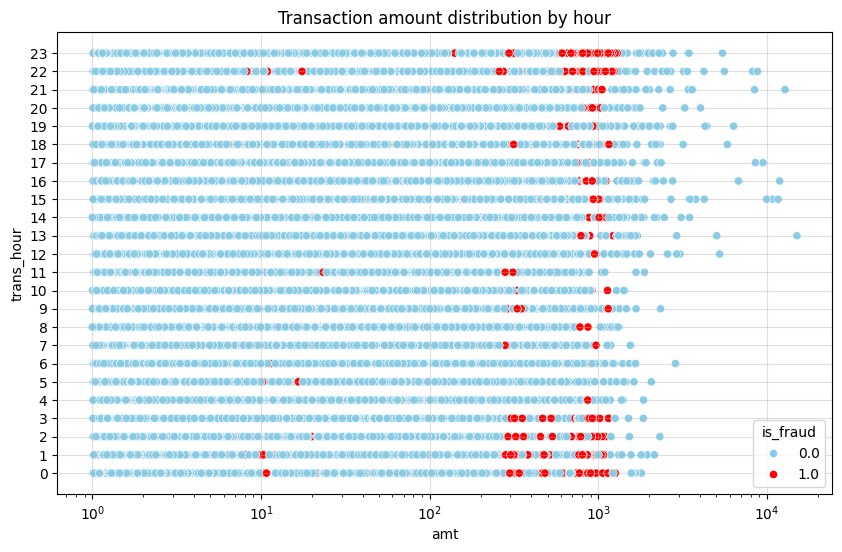

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data, y='trans_hour', x='amt', hue='is_fraud', palette=['skyblue', 'red'])
plt.yticks(np.arange(0, 24, 1))
plt.xscale('log')
plt.grid(True, alpha=.4)
plt.title('Transaction amount distribution by hour')
plt.show()

In [44]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [45]:
# df = pd.DataFrame(scaled_features, columns=features.columns)
# df.info()
# df.describe()

In [48]:
iso = IsolationForest(contamination=.02, random_state=37)
labels = iso.fit_predict(scaled_features)

In [49]:
data['is_anomaly'] = np.where(labels == -1, 1, 0)

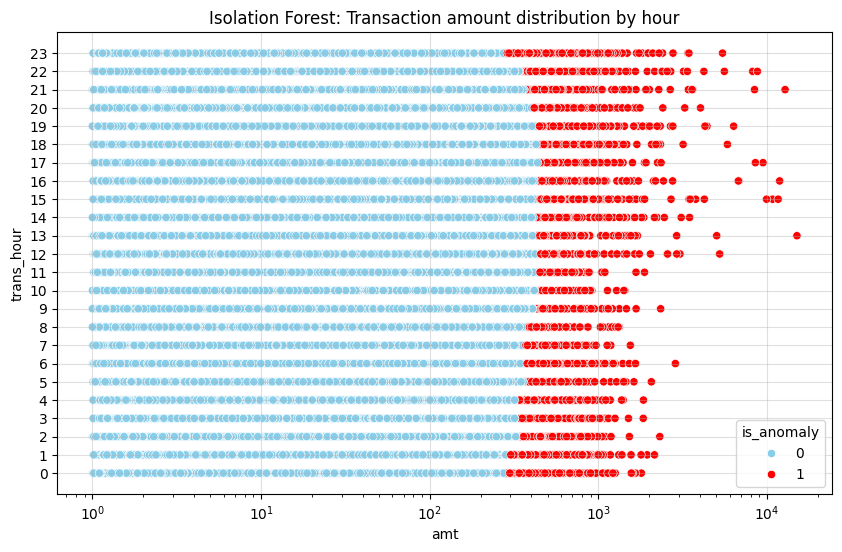

In [62]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data, y='trans_hour', x='amt', hue='is_anomaly', palette=['skyblue', 'red'])
plt.yticks(np.arange(0, 24, 1))
plt.xscale('log')
plt.grid(True, alpha=.4)
plt.title('Isolation Forest: Transaction amount distribution by hour')
plt.show()

In [67]:
print("Isoltaion Forest Performance Statistics:\n")
print(f"Number of anomalies detected: {data['is_anomaly'].sum():,}")
print(f"Percentage of anomalies: {data['is_anomaly'].sum() / len(data) *100:.3f}%")

print(f"\nActual Frauds: {data['is_fraud'].sum():,}")
true_positive = data[(data['is_anomaly'] == 1) & (data['is_fraud'] == 1)]
false_positive = data[(data['is_anomaly'] == 1) & (data['is_fraud'] == 0)]
false_negative = data[(data['is_anomaly'] == 0) & (data['is_fraud'] == 1)]
print(f"True positive by Isolation Forest: {len(true_positive):,}")
print(f"False positives identified by Isolation Forest: {len(false_positive):,}")
print(f"False negatives identified by Isolation Forest: {len(false_negative):,}")
print(f"Precision (% correct frauds): {len(true_positive) / data['is_anomaly'].sum() * 100:.2f}%")
print(f"Recall (% frauds identified): {len(true_positive) / (len(true_positive) + len(false_negative)) * 100:.2f}%")

Isoltaion Forest Performance Statistics:

Number of anomalies detected: 3,079
Percentage of anomalies: 1.998%

Actual Frauds: 1,411.0
True positive by Isolation Forest: 803
False positives identified by Isolation Forest: 2,276
False negatives identified by Isolation Forest: 608
Precision (% correct frauds): 26.08%
Recall (% frauds identified): 56.91%


In [72]:
model = NearestNeighbors(n_neighbors=100)
model.fit(scaled_features)

distances, indices = model.kneighbors(scaled_features)
outlier_score = distances[:, -1]

threshold = np.percentile(outlier_score, 99)
data['is_outlier'] = np.where(outlier_score > threshold, 1, 0)

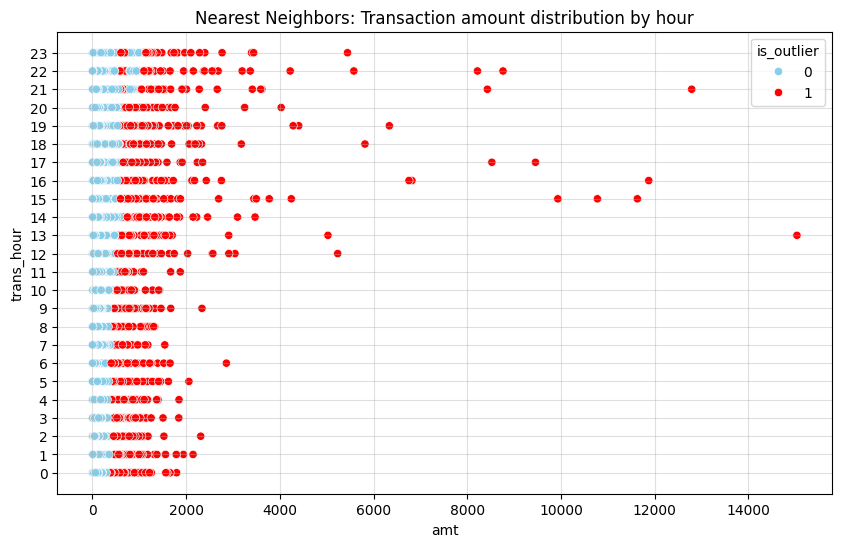

In [75]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data, y='trans_hour', x='amt', hue='is_outlier', palette=['skyblue', 'red'])
plt.yticks(np.arange(0, 24, 1))
# plt.xscale('log')
plt.grid(True, alpha=.4)
plt.title('Nearest Neighbors: Transaction amount distribution by hour')
plt.show()

In [74]:
print("Nearest Neighbors Performance Statistics:\n")
print(f"Number of anomalies detected: {data['is_outlier'].sum():,}")
print(f"Percentage of anomalies: {data['is_outlier'].sum() / len(data) *100:.3f}%")

print(f"\nActual Frauds: {data['is_fraud'].sum():,}")
true_positive = data[(data['is_outlier'] == 1) & (data['is_fraud'] == 1)]
false_positive = data[(data['is_outlier'] == 1) & (data['is_fraud'] == 0)]
false_negative = data[(data['is_outlier'] == 0) & (data['is_fraud'] == 1)]
print(f"True positive by Isolation Forest: {len(true_positive):,}")
print(f"False positives identified by Isolation Forest: {len(false_positive):,}")
print(f"False negatives identified by Isolation Forest: {len(false_negative):,}")
print(f"Precision (% correct frauds): {len(true_positive) / data['is_outlier'].sum() * 100:.2f}%")
print(f"Recall (% frauds identified): {len(true_positive) / (len(true_positive) + len(false_negative)) * 100:.2f}%")

Nearest Neighbors Performance Statistics:

Number of anomalies detected: 1,541
Percentage of anomalies: 1.000%

Actual Frauds: 1,411.0
True positive by Isolation Forest: 366
False positives identified by Isolation Forest: 1,175
False negatives identified by Isolation Forest: 1,045
Precision (% correct frauds): 23.75%
Recall (% frauds identified): 25.94%
